<a href="https://colab.research.google.com/github/k-workproject/data-skills-roadmap/blob/main/python-project/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Load Data

## Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Dataset

In [3]:
path = '/content/drive/My Drive/titanic-survival-prediction'

In [4]:
train_path = os.path.join(path,'train.csv')
test_path = os.path.join(path,'test.csv')

In [5]:
train_data = pd.read_csv(train_path)
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
test_data = pd.read_csv(test_path)
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Check Data Structure

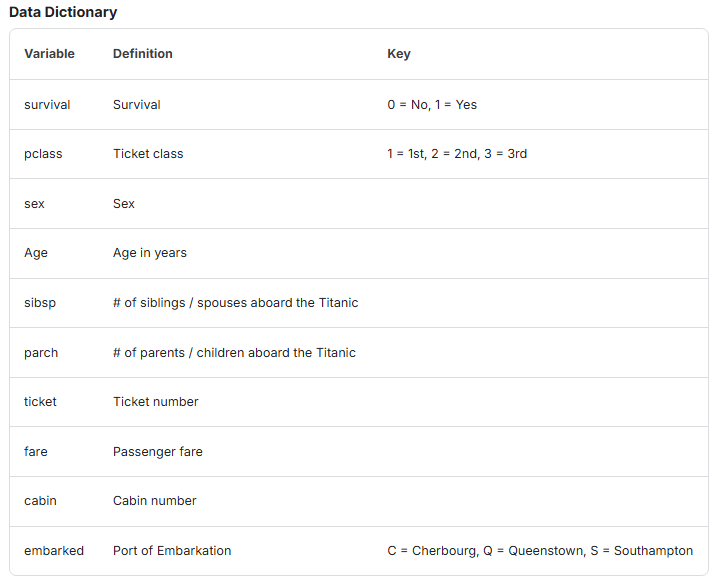

**Variable Notes**

**1. pclass:** A proxy for socio-economic status (SES)

  * 1st = Upper

  * 2nd = Middle

  * 3rd = Lower

**2. age:** Age is fractional if less than 1.

  * If the age is estimated, is it in the form of xx.5

**3. sibsp:** The dataset defines family relations in this way...

  * Sibling = brother, sister, stepbrother, stepsister

  * Spouse = husband, wife (mistresses and fiancés were ignored)

**4. parch:** The dataset defines family relations in this way...

  * Parent = mother, father
  
  * Child = daughter, son, stepdaughter, stepson

  * Some children travelled only with a nanny, therefore parch=0 for them.

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Cleaning

In [10]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
train_data['Age'] = train_data.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median())) # เติมค่า Missing Value ของ Age เฉพาะแถวที่ขาดหาย โดยใช้ค่า Median ของแต่ละกลุ่ม (แบ่งกลุ่มตาม Pclass และ Sex)

In [12]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0]) # เติมค่า Missing Value ของ Embarked เฉพาะแถวที่ขาดหาย โดยใช้ค่า Mode ของข้อมูล

In [14]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
train_data['Deck'] = train_data['Cabin'].str[0].fillna('U') # สร้าง column สำหรับแยกตัวอักษรใน Cabin และเติมค่า Missing Value ของ Cabin ด้วย U คือ Unknow เนื่องจากไม่ทราบข้อมูล

In [16]:
train_data.drop('Cabin', axis=1, inplace=True)

In [17]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
train_data.groupby('Deck').agg(
    count=('Survived', 'count'),
    survival_rate=('Survived', 'mean'),
    main_pclass=('Pclass', lambda x: x.mode()[0])
) # หาจำนวนคนและอัตราค่าเฉลี่ยของ Survived แต่ละกลุ่ม

,count,survival_rate,main_pclass
Deck,,,
A,15,0.466667,1
B,47,0.744681,1
C,59,0.593220,1
D,33,0.757576,1
E,32,0.750000,1
F,13,0.615385,2
G,4,0.500000,3
T,1,0.000000,1
U,687,0.299854,3


In [19]:
train_data.duplicated().sum()

np.int64(0)

In [20]:
train_data['Pclass'] = train_data['Pclass'].astype('category') # เปลี่ยน type ข้อมูล
train_data['Deck'] = train_data['Deck'].astype('category')
train_data['Sex'] = train_data['Sex'].astype('category')
train_data['Embarked'] = train_data['Embarked'].astype('category')

In [21]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  Deck         891 non-null    category
dtypes: category(4), float64(2), int64(4), object(2)
memory usage: 60.0+ KB


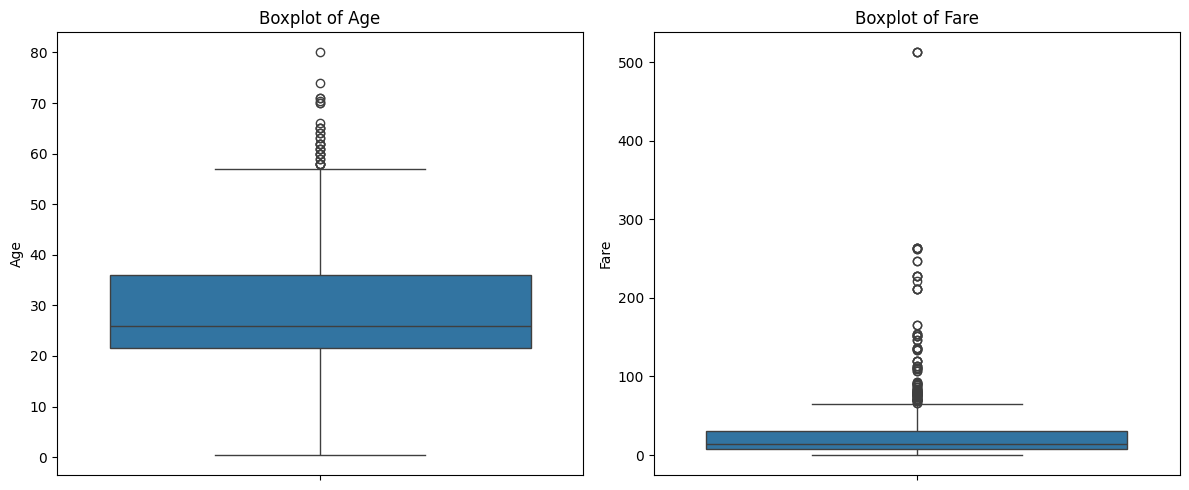

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(y = train_data['Age'], ax = axes[0])
axes[0].set_title('Boxplot of Age')

sns.boxplot(y = train_data['Fare'], ax = axes[1])
axes[1].set_title('Boxplot of Fare')

plt.tight_layout()
plt.show()

In [23]:
train_data.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
train_data['Fare_log'] = np.log1p(train_data['Fare'])

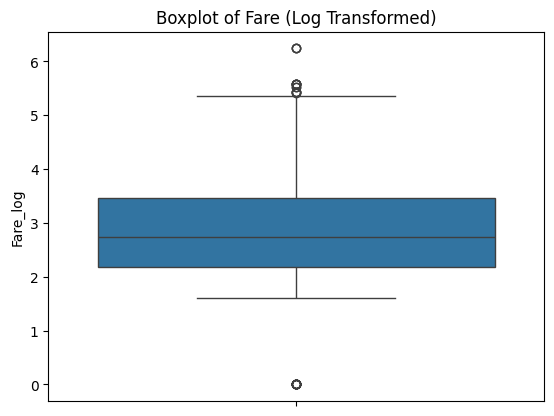

In [25]:
sns.boxplot(y = train_data['Fare_log'])
plt.title('Boxplot of Fare (Log Transformed)')
plt.show()

In [26]:
scaler = StandardScaler()

train_data[['Age_scaled', 'Fare_log_scaled']] = scaler.fit_transform(
    train_data[['Age', 'Fare_log']]
)

In [27]:
train_data[['Age', 'Age_scaled', 'Fare', 'Fare_log', 'Fare_log_scaled']].describe()

,Age,Age_scaled,Fare,Fare_log,Fare_log_scaled
count,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02
mean,29.112424,2.153160e-16,32.204208,2.962246,-1.714553e-16
std,13.304424,1.000562e+00,49.693429,0.969048,1.000562e+00
min,0.420000,-2.157819e+00,0.000000,0.000000,-3.058578e+00
25%,21.500000,-5.724938e-01,7.910400,2.187218,-8.002318e-01
50%,26.000000,-2.340704e-01,14.454200,2.737881,-2.316613e-01
75%,36.000000,5.179814e-01,31.000000,3.465736,5.198636e-01
max,80.000000,3.827009e+00,512.329200,6.240917,3.385294e+00


# Feature Engineering

## สร้าง Title จาก Name

In [28]:
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(train_data['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [29]:
# ขั้นที่ 1: รวม title ที่มีความหมายตรงกันก่อน
train_data['Title'] = train_data['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# ขั้นที่ 2: ค่อยรวมกลุ่มที่เหลือซึ่งพบน้อยเป็น Rare
title_counts = train_data['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
train_data['Title'] = train_data['Title'].replace(rare_titles, 'Rare')

print(train_data['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


## สร้าง FamilySize และ IsAlone

In [30]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)

train_data[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [31]:
print(train_data.groupby('Title')['Survived'].agg(['count', 'mean']))
print(train_data.groupby('IsAlone')['Survived'].agg(['count', 'mean']))

        count      mean
Title                  
Master     40  0.575000
Miss      185  0.702703
Mr        517  0.156673
Mrs       126  0.793651
Rare       23  0.347826
         count      mean
IsAlone                 
0          354  0.505650
1          537  0.303538


In [32]:
train_data = pd.get_dummies(train_data, columns=['Sex', 'Embarked', 'Deck', 'Title'], drop_first=True)
train_data.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Fare_log,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2.110213,...,False,False,False,False,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,4.280593,...,False,False,False,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,2.188856,...,False,False,False,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,3.990834,...,False,False,False,False,False,False,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,2.202765,...,False,False,False,False,False,True,False,True,False,False


In [33]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    category
 3   Name             891 non-null    object  
 4   Age              891 non-null    float64 
 5   SibSp            891 non-null    int64   
 6   Parch            891 non-null    int64   
 7   Ticket           891 non-null    object  
 8   Fare             891 non-null    float64 
 9   Fare_log         891 non-null    float64 
 10  Age_scaled       891 non-null    float64 
 11  Fare_log_scaled  891 non-null    float64 
 12  FamilySize       891 non-null    int64   
 13  IsAlone          891 non-null    int64   
 14  Sex_male         891 non-null    bool    
 15  Embarked_Q       891 non-null    bool    
 16  Embarked_S       891 non-null    bool    
 1

In [34]:
train_data['Pclass'] = train_data['Pclass'].astype(int)
train_data = train_data.drop(['Name', 'Ticket'], axis=1)

In [35]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Age              891 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Fare_log         891 non-null    float64
 8   Age_scaled       891 non-null    float64
 9   Fare_log_scaled  891 non-null    float64
 10  FamilySize       891 non-null    int64  
 11  IsAlone          891 non-null    int64  
 12  Sex_male         891 non-null    bool   
 13  Embarked_Q       891 non-null    bool   
 14  Embarked_S       891 non-null    bool   
 15  Deck_B           891 non-null    bool   
 16  Deck_C           891 non-null    bool   
 17  Deck_D          

# Exploratory Data Analysis (EDA)

## Sex vs Survived

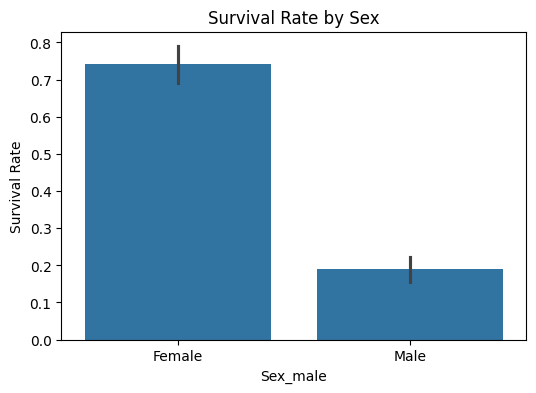

In [36]:
plt.figure(figsize=(6, 4))
sns.barplot(data=train_data, x='Sex_male', y='Survived')
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

## Pclass vs Survived

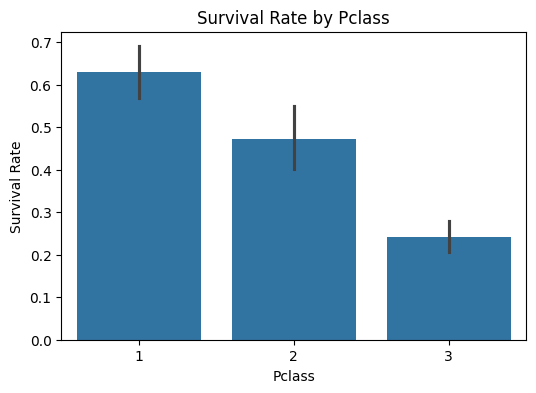

In [37]:
plt.figure(figsize=(6, 4))
sns.barplot(data=train_data, x='Pclass', y='Survived')
plt.title('Survival Rate by Pclass')
plt.ylabel('Survival Rate')
plt.show()

## Age Distribution vs Survived

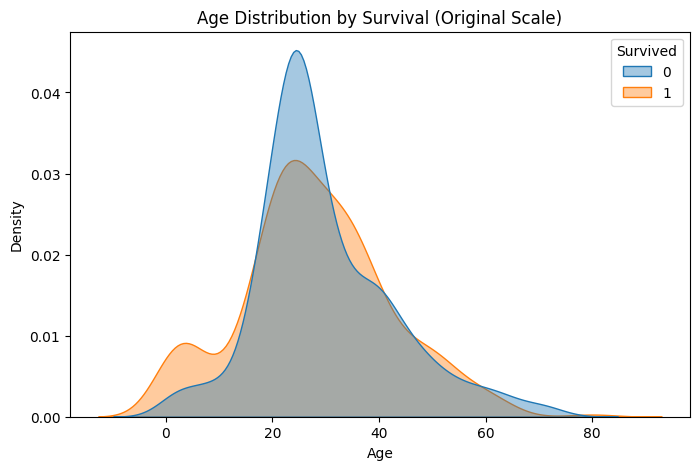

In [38]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=train_data, x='Age', hue='Survived', fill=True, common_norm=False, alpha=0.4)
plt.title('Age Distribution by Survival (Original Scale)')
plt.show()

## Fare vs Survived

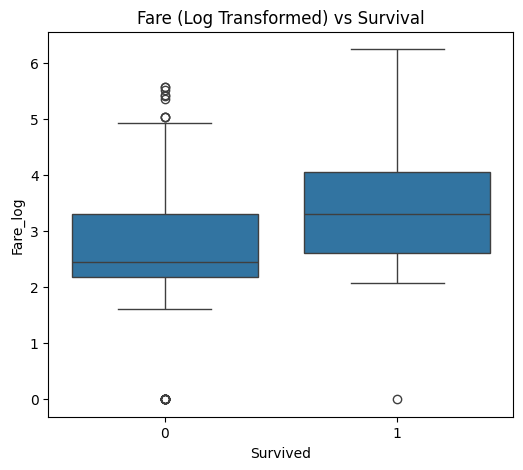

In [39]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=train_data, x='Survived', y='Fare_log')
plt.title('Fare (Log Transformed) vs Survival')
plt.ylabel('Fare_log')
plt.show()

## Embarked และ FamilySize vs Survived

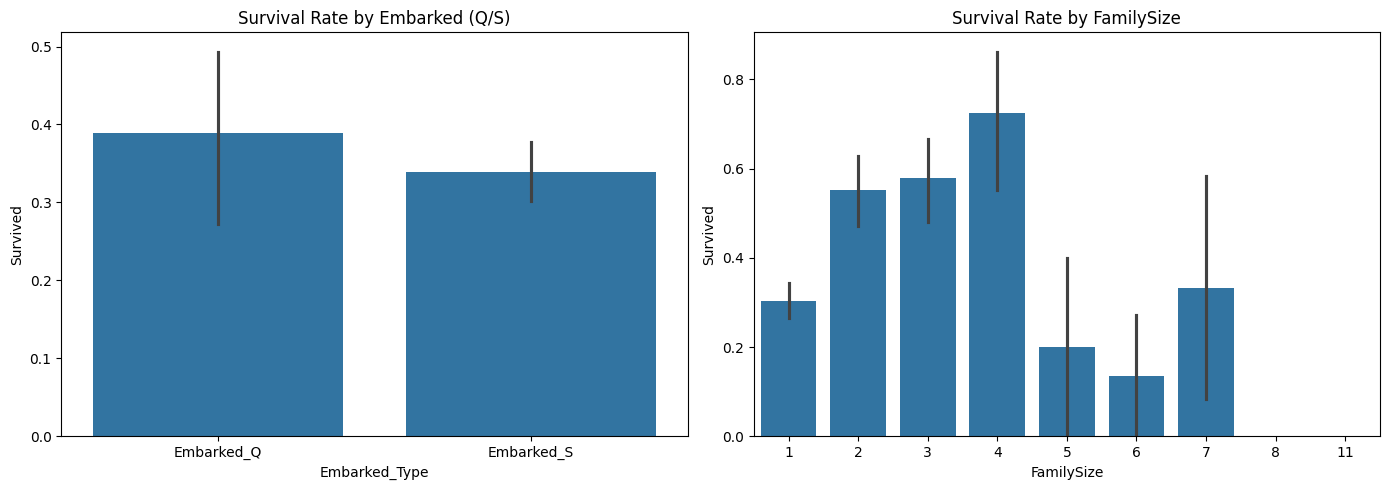

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

embarked_survival = train_data.melt(
    id_vars='Survived',
    value_vars=['Embarked_Q', 'Embarked_S'],
    var_name='Embarked_Type',
    value_name='Is_This_Port'
)
embarked_survival = embarked_survival[embarked_survival['Is_This_Port'] == True]

sns.barplot(data=embarked_survival, x='Embarked_Type', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Embarked (Q/S)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Embarked_Q', 'Embarked_S'])

sns.barplot(data=train_data, x='FamilySize', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by FamilySize')

plt.tight_layout()
plt.show()

## Correlation Heatmap

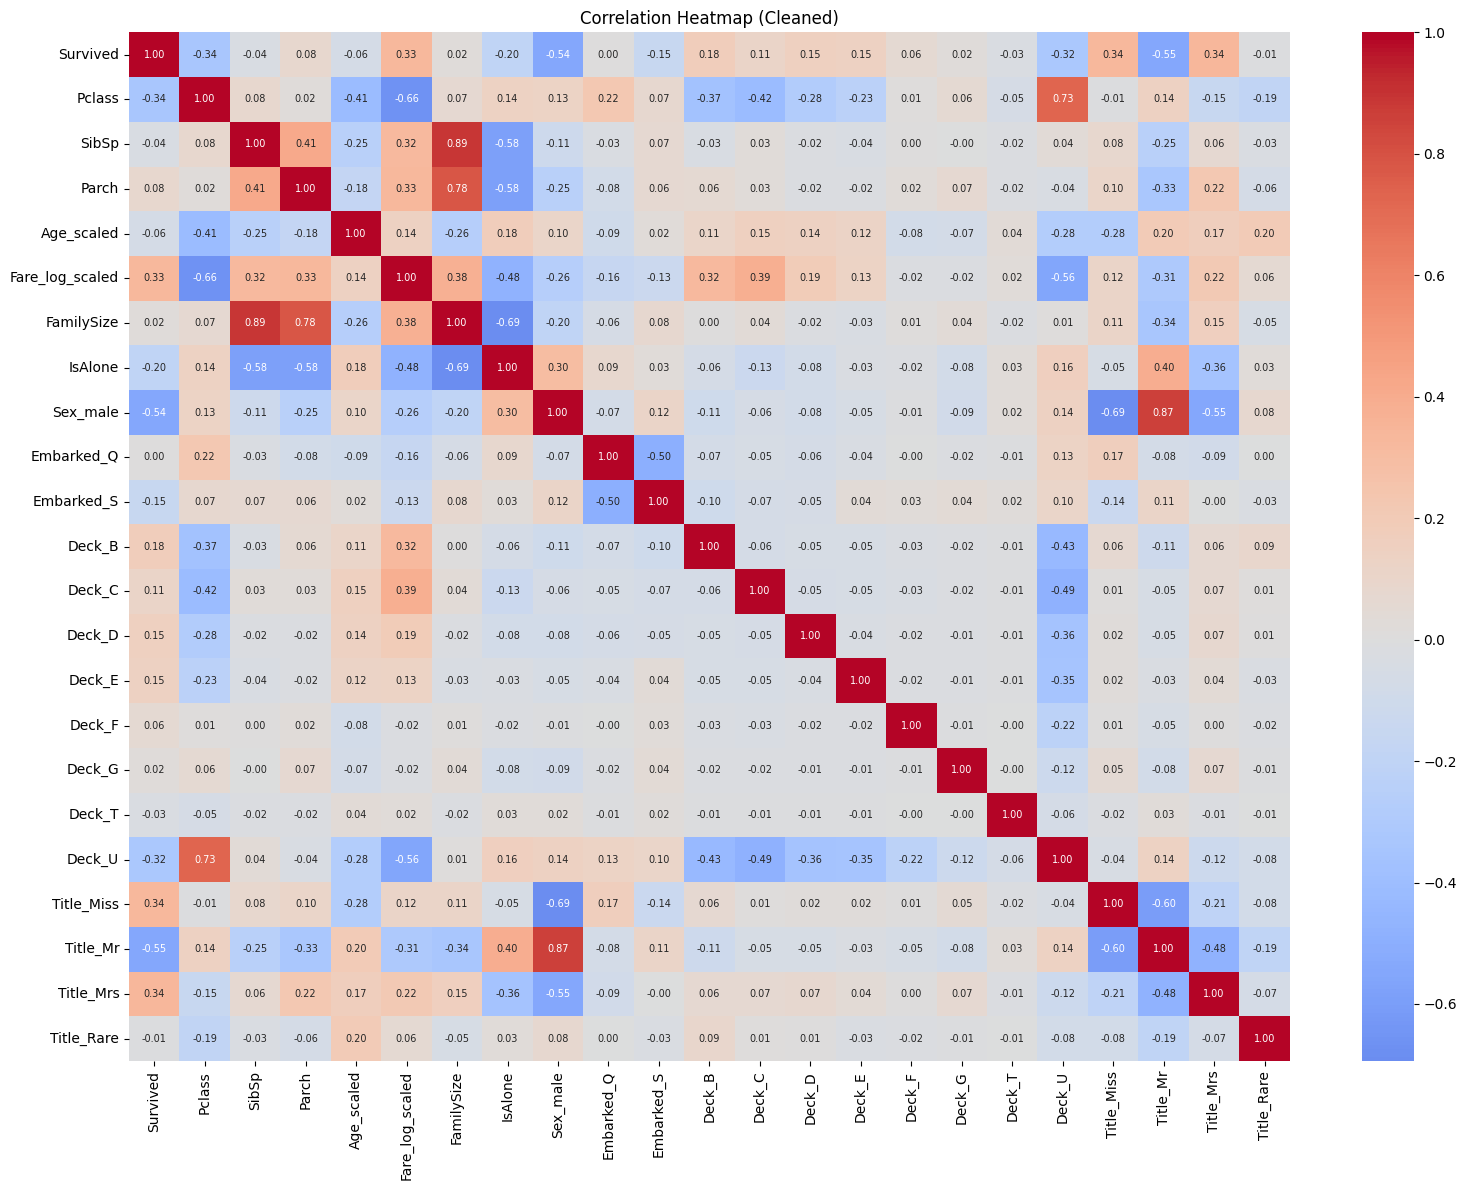

In [41]:
plt.figure(figsize=(16, 12))
corr = train_data.drop(['PassengerId', 'Age', 'Fare', 'Fare_log'], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation Heatmap (Cleaned)')
plt.tight_layout()
plt.show()

## 📊 Summary: Data Preparation ก่อนเข้า Modeling

### Data Cleaning
- จัดการ Missing Value ครบ 3 จุด:
  - `Age` → เติมด้วย median แยกตามกลุ่ม Pclass + Sex
  - `Embarked` → เติมด้วยค่าที่พบบ่อยที่สุด (mode)
  - `Cabin` → ดึงเป็นฟีเจอร์ `Deck` แทนการ drop ทิ้ง เพราะพบว่าการมี/ไม่มีข้อมูล Cabin มีผลต่ออัตรารอดชัดเจน
- ไม่พบ Duplicate row ในข้อมูล
- จัดการ Outlier ของ `Fare` ด้วย Log Transform เนื่องจากมีการกระจายตัวเบ้ขวารุนแรง
- `Age` ตัดสินใจไม่แตะต้อง Outlier เพราะค่าที่ดูเหมือนผิดปกติทางสถิติ (ผู้สูงอายุ 60-80 ปี) เป็นข้อมูลที่สมเหตุสมผลตามความเป็นจริง

### Feature Engineering
- สร้าง `Title` จากคำนำหน้าใน `Name` แล้วรวมกลุ่มที่พบน้อยเป็น `Rare` (เหลือ 5 กลุ่ม: Mr, Miss, Mrs, Master, Rare)
- สร้าง `FamilySize` และ `IsAlone` จาก `SibSp` + `Parch`
- แปลง Categorical ทั้งหมด (`Sex`, `Embarked`, `Deck`, `Title`) เป็นตัวเลขด้วย One-Hot Encoding

### Key Insights จาก EDA

| ปัจจัย | พบว่า |
|---|---|
| เพศ | หญิงรอด ~74% ชายรอด ~19% — ปัจจัยที่มีผลแรงที่สุด |
| ชั้นโดยสาร (Pclass) | ยิ่งชั้นสูง (1) ยิ่งรอดมาก (~63%) ชั้น 3 รอดน้อยสุด (~24%) |
| อายุ | เด็กเล็ก (0-10 ปี) มีอัตรารอดสูงกว่ากลุ่มอื่นชัดเจน สอดคล้องหลัก "เด็กและผู้หญิงก่อน" |
| Fare | คนที่จ่ายค่าตั๋วแพงกว่ามีแนวโน้มรอดสูงกว่า (สัมพันธ์กับ Pclass) |
| ขนาดครอบครัว | รูปแบบไม่เป็นเส้นตรง ครอบครัวขนาด 2-4 คนรอดมากสุด ส่วนคนเดินทางคนเดียวและครอบครัวใหญ่มาก (5+) รอดน้อยกว่า |
| Deck/Cabin | คนที่ไม่มีข้อมูล Cabin (ส่วนใหญ่ Pclass 2-3) รอดแค่ ~30% ต่ำกว่ากลุ่มที่มีข้อมูล Cabin มาก |

### ปัญหาที่พบและแก้ไขแล้ว
- พบ **Multicollinearity รุนแรง** (correlation = 1.00) ระหว่างคอลัมน์ดิบกับคอลัมน์ที่ผ่านการ transform แล้ว (`Age`/`Age_scaled`, `Fare_log`/`Fare_log_scaled`) → ตัดคอลัมน์ดิบทิ้ง เก็บเฉพาะเวอร์ชัน scaled
- พบคู่ฟีเจอร์ที่สัมพันธ์กันสูง เช่น `SibSp`/`FamilySize` (0.89), `Sex_male`/`Title_Mr` (0.87) — รับทราบไว้ พิจารณาตัดออกอีกครั้งตามประเภทโมเดลที่ใช้

### ฟีเจอร์ที่สัมพันธ์กับการรอดชีวิตแรงที่สุด (เรียงตามค่า Correlation)
1. `Title_Mr` (-0.55)
2. `Sex_male` (-0.54)
3. `Title_Mrs` / `Title_Miss` (+0.34)
4. `Pclass` (-0.34)
5. `Fare_log` (+0.33)

---

**✅ ข้อมูลพร้อมเข้าโมเดล:** 891 แถว, ฟีเจอร์ตัวเลขล้วน (ไม่มี object/category), ตัดคอลัมน์ซ้ำซ้อนออกแล้ว

# Modeling